In [4]:
import polars as pl

DATASET = 'gex_pre'

gex = pl.read_csv(f'../dataset/created/gex/{DATASET}.csv')
gex

patientID,sample_id,HGNC,value,source,Method
str,str,str,f64,str,str
"""LM_1""","""LMSAM_1""","""BRAF""",7.60798,"""Louveau et al.""","""qPCR"""
"""LM_1""","""LMSAM_1""","""RAF1""",16.095204,"""Louveau et al.""","""qPCR"""
"""LM_1""","""LMSAM_1""","""ARAF""",4.1515,"""Louveau et al.""","""qPCR"""
"""LM_1""","""LMSAM_1""","""PDGFRB""",1.199885,"""Louveau et al.""","""qPCR"""
"""LM_1""","""LMSAM_1""","""IGF1R""",5.47246,"""Louveau et al.""","""qPCR"""
…,…,…,…,…,…
"""HL_Shi-43""","""Pt17-baseline""","""ZYG11A""",0.0625681,"""Hugo et al.""","""RNA-seq"""
"""HL_Shi-43""","""Pt17-baseline""","""ZYG11B""",5.74608,"""Hugo et al.""","""RNA-seq"""
"""HL_Shi-43""","""Pt17-baseline""","""ZYX""",45.907933,"""Hugo et al.""","""RNA-seq"""


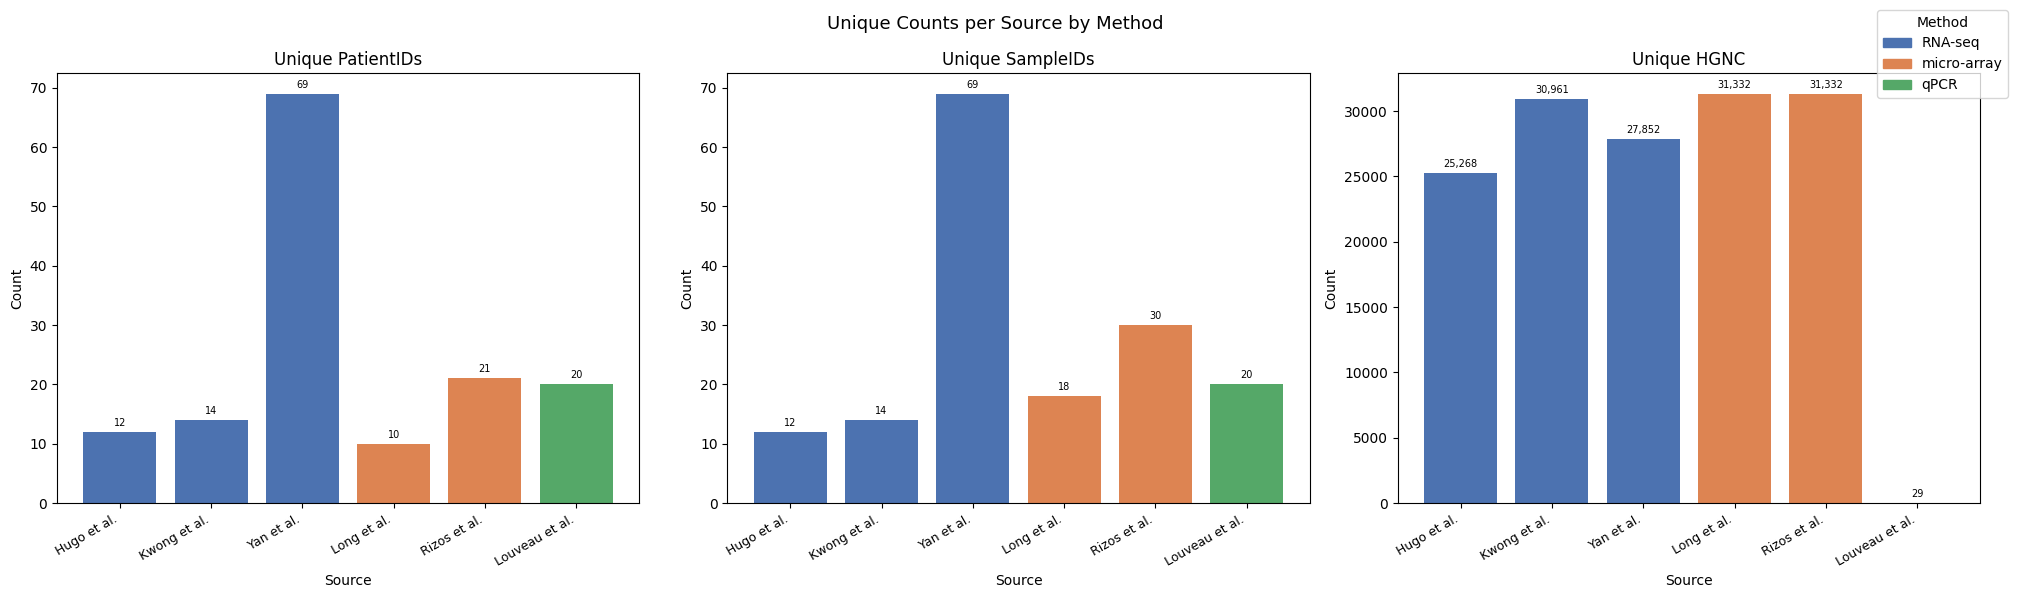

In [10]:
import matplotlib.pyplot as plt
import numpy as np

hgnc_col = next((c for c in gex.columns if 'hgnc' in c.lower() or 'gene' in c.lower()), None)

stats = gex.group_by(["source", "Method"]).agg([
    pl.col("patientID").n_unique().alias("unique_patients"),
    pl.col("sample_id").n_unique().alias("unique_samples"),
    pl.col(hgnc_col).n_unique().alias("unique_genes"),
]).to_pandas()

method_colors = {"RNA-seq": "#4C72B0", "micro-array": "#DD8452", "qPCR": "#55A868"}
method_order = ["RNA sequencing", "micro-array", "qPCR"]

# Preserve original source order, grouped by method
rna_sources = stats[stats["Method"] == "RNA-seq"].sort_values("source")["source"].tolist()
micro_array_sources = stats[stats["Method"] == "micro-array"].sort_values("source")["source"].tolist()
qpcr_sources = stats[stats["Method"] == "qPCR"].sort_values("source")["source"].tolist()
ordered_sources = rna_sources + micro_array_sources + qpcr_sources

df = stats.set_index("source").loc[ordered_sources].reset_index()

metrics = [
    ("unique_patients", "Unique PatientIDs"),
    ("unique_samples",  "Unique SampleIDs"),
    ("unique_genes",    f"Unique {hgnc_col}"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (col, title) in zip(axes, metrics):
    x = np.arange(len(df))
    colors = [method_colors[m] for m in df["Method"]]
    bars = ax.bar(x, df[col], color=colors)

    ax.set_title(title)
    ax.set_xlabel("Source")
    ax.set_ylabel("Count")
    ax.set_xticks(x)
    ax.set_xticklabels(df["source"], rotation=30, ha="right", fontsize=9)

    for bar, h in zip(bars, df[col]):
        ax.annotate(f"{h:,}", xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=7)

    # Divider between method groups

handles = [plt.Rectangle((0,0),1,1, color=c, label=m) for m, c in method_colors.items()]
fig.legend(handles=handles, title="Method", loc="upper right", bbox_to_anchor=(1.01, 1))

plt.suptitle("Unique Counts per Source by Method", fontsize=13)
plt.tight_layout()
plt.show()
